In [11]:
import logging
from typing import List, Optional, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf


def setup_logging(level=logging.INFO):
    """Configure notebook logging with concise output."""
    logging.basicConfig(level=level, format='%(asctime)s - %(levelname)s - %(message)s')
    logging.getLogger('yfinance').setLevel(logging.CRITICAL)


def get_stock_data(ticker_symbol: Union[str, List[str]], start_date: str
        ) -> Optional[pd.DataFrame]:
    """Download historical price data."""
    try:
        data = yf.download(
            ticker_symbol,
            start=start_date,
            group_by='ticker',
            auto_adjust=True,
            progress=False,
        )
        if data.empty:
            logger.warning(f'No data retrieved for: {ticker_symbol}')
            return None
        return data
    except Exception as exc:
        logger.error(f'Error downloading data for {ticker_symbol}: {exc}')
        return None


def get_close_series(df: pd.DataFrame, ticker: str) -> pd.Series:
    """Return the close-price series for flat or MultiIndex yfinance output."""
    if isinstance(df.columns, pd.MultiIndex):
        for candidate in ((ticker, 'Close'), ('Close', ticker)):
            if candidate in df.columns:
                return df[candidate].dropna()
        raise KeyError(f'Close price column not found for {ticker}.')

    if 'Close' in df.columns:
        return df['Close'].dropna()

    raise KeyError(f'Close price column not found for {ticker}.')


def run_monte_carlo(close_prices: pd.Series, num_days: int, num_simulations: int):
    """Run a GBM Monte Carlo simulation from a close-price series."""
    returns = close_prices.pct_change(fill_method=None).dropna()
    mu = returns.mean()
    sigma = returns.std()
    last_price = close_prices.iloc[-1]

    simulation_df = np.zeros((num_days, num_simulations))
    for i in range(num_simulations):
        price_list = [last_price]
        for _ in range(num_days):
            next_price = price_list[-1] * np.exp((mu - 0.5 * sigma**2) + sigma * np.random.normal())
            price_list.append(next_price)
        simulation_df[:, i] = price_list[1:]

    final_prices = simulation_df[-1, :]
    median_final_price = np.median(final_prices)
    most_likely_price_index = np.argmin(np.abs(final_prices - median_final_price))
    most_likely_path = simulation_df[:, most_likely_price_index]
    return simulation_df, final_prices, median_final_price, most_likely_path


START_DATE = '1950-01-01'
NUM_SIMULATIONS = 10000
NUM_DAYS_SINGLE_TICKER = 252
NUM_DAYS_MULTIPLE_TICKERS = 22

setup_logging()
logger = logging.getLogger(__name__)
sns.set_theme(style='darkgrid')


# Un Ticker

En esta sección la data representa la historia de precios ajustados de un solo activo. La intención no es extraer una predicción puntual, sino observar cómo el comportamiento histórico del precio de cierre puede traducirse en un rango de trayectorias futuras plausibles.

El pipeline, visto desde la data, sigue esta secuencia: primero se descarga la serie histórica del activo; después se toma el cierre ajustado como referencia principal; luego se calculan los retornos diarios para medir la variación relativa del precio; finalmente, esa estructura histórica de movimiento alimenta la simulación de escenarios. En este bloque, `ticker` identifica el activo, `close_prices` concentra la serie base, y `returns`, `mu` y `sigma` resumen cómo se ha movido esa data en el tiempo.

In [12]:
ticker = 'PLTR'
df = get_stock_data(ticker, START_DATE)
if df is None:
    raise ValueError(f'No se pudieron descargar datos para {ticker}.')

close_prices = get_close_series(df, ticker)
returns = close_prices.pct_change(fill_method=None).dropna()


In [13]:
num_simulations = NUM_SIMULATIONS
num_days = NUM_DAYS_SINGLE_TICKER
last_price = close_prices.iloc[-1]

simulation_df = np.zeros((num_days, num_simulations))
mu = returns.mean()
sigma = returns.std()


In [14]:
for i in range(num_simulations):
  price_list=[last_price]
  for j in range(num_days):
    price=price_list[-1] * np.exp((mu - 0.5 * sigma**2) + sigma * np.random.normal())
    price_list.append(price)
  simulation_df[:,i]=price_list[1:]

final_prices=simulation_df[-1,:]
median_final_prices=np.median(final_prices)

most_likely_price_index=np.argmin(np.abs(final_prices-median_final_prices))
most_likely_price_simulation=simulation_df[:,most_likely_price_index]

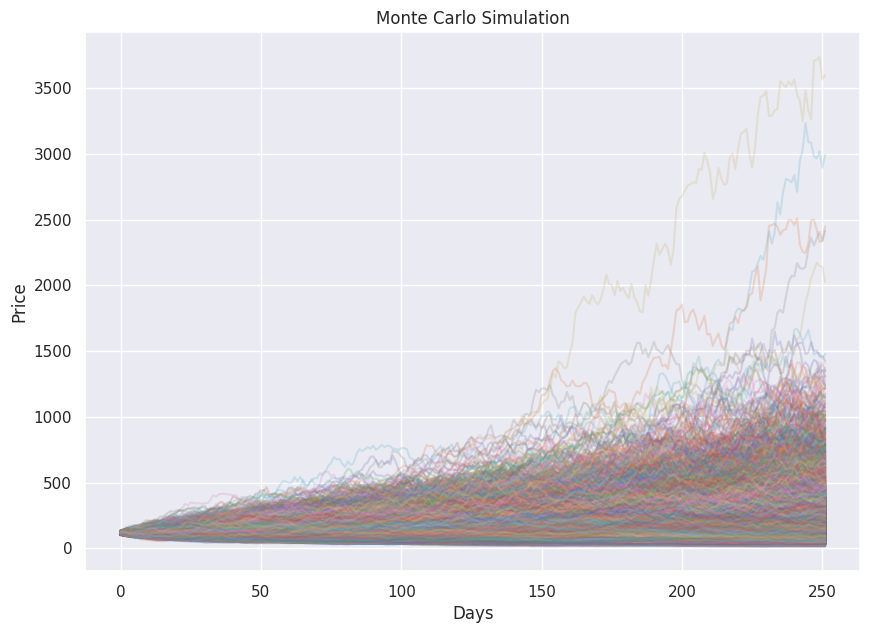

Resumen de la simulación para PLTR:
- Precio más probable al final del horizonte: 179.61
- Mediana de precios finales: 179.65


In [15]:
plt.figure(figsize=(10,7))
plt.plot(simulation_df, alpha=0.25)
plt.title("Monte Carlo Simulation")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

print(f"Resumen de la simulación para {ticker}:")
print(f"- Precio más probable al final del horizonte: {most_likely_price_simulation[-1]:.2f}")
print(f"- Mediana de precios finales: {median_final_prices:.2f}")


# Varios Tickers

En esta sección la data ya no describe un único activo, sino un conjunto comparable de series históricas. Cada ticker conserva su propio historial de cierres y, por lo tanto, su propia firma de variación, lo que permite contrastar escenarios simulados entre empresas sin reducir el análisis a una sola narrativa de mercado.

El pipeline parte de una descarga conjunta de precios históricos, separa la serie de cierre de cada activo, calcula sus retornos de manera individual y ejecuta una simulación independiente para cada ticker. Después, los resultados se agrupan para comparar precios finales probables, medianas e intervalos. En este bloque, `mis_tickers` define el universo observado, `df2` reúne la data histórica conjunta y los diccionarios de resultados almacenan la salida consolidada del análisis comparativo.

In [16]:
mis_tickers = ['PLTR', 'MSFT', 'GOOGL', 'META', 'LMT', 'CVX']

df2 = get_stock_data(mis_tickers, START_DATE)
if df2 is None:
    raise ValueError('No se pudieron descargar datos para la lista de tickers.')

for ticker in mis_tickers:
    close_prices = get_close_series(df2, ticker)
    df2[(ticker, 'Returns')] = close_prices.reindex(df2.index).pct_change(fill_method=None)


In [17]:
num_simulations = 10000
num_days = 22  # predict horizon

# Dictionaries to store results for each ticker
all_ticker_simulation_dfs = {}
all_ticker_most_likely_prices = {}
all_ticker_median_final_prices = {}

--------- Simulating for ['PLTR', 'MSFT', 'GOOGL', 'META', 'LMT', 'CVX'] ---------


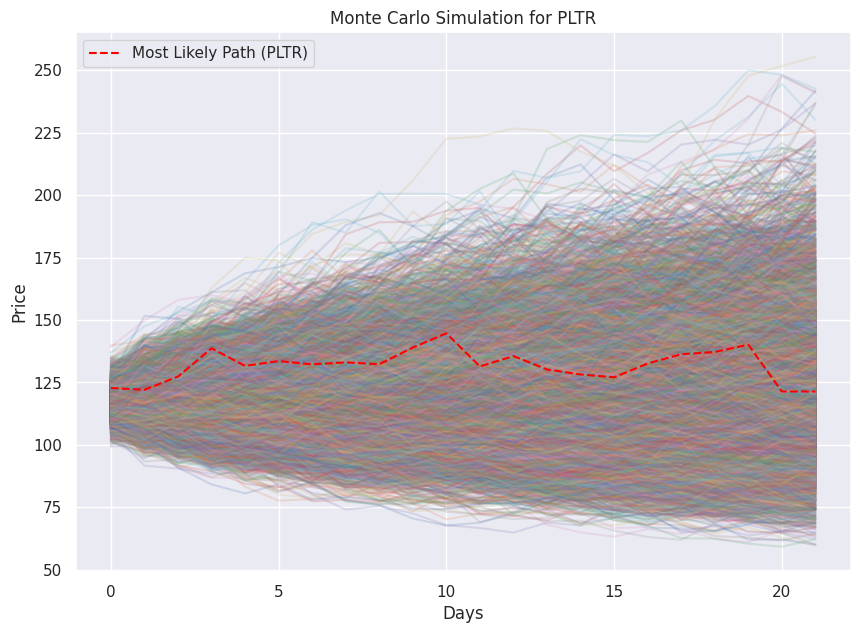

-------- Results for PLTR ---------
Median Final Simulated Price: $121.39
Most Likely Final Simulated Price: $121.39
---------------------------------------------------------------------------


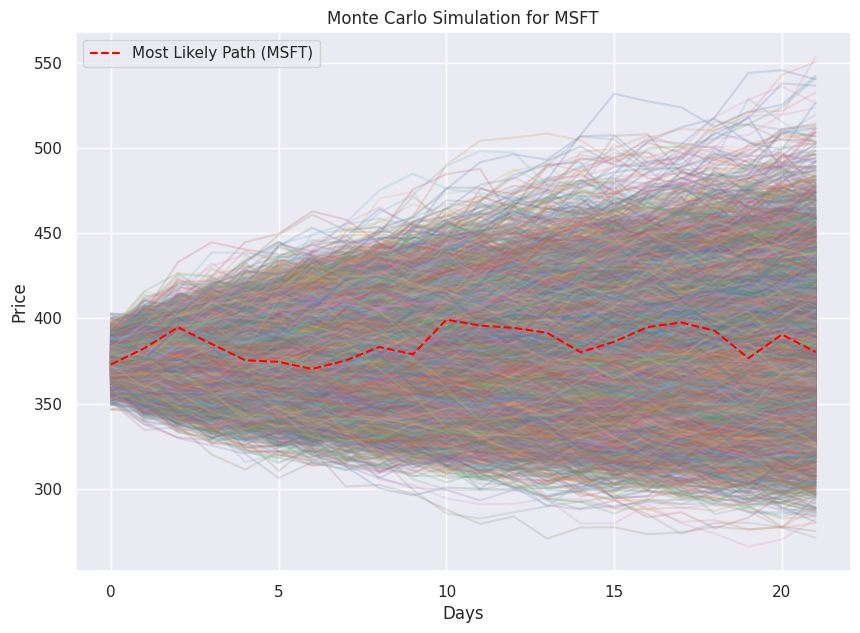

-------- Results for MSFT ---------
Median Final Simulated Price: $380.24
Most Likely Final Simulated Price: $380.25
---------------------------------------------------------------------------


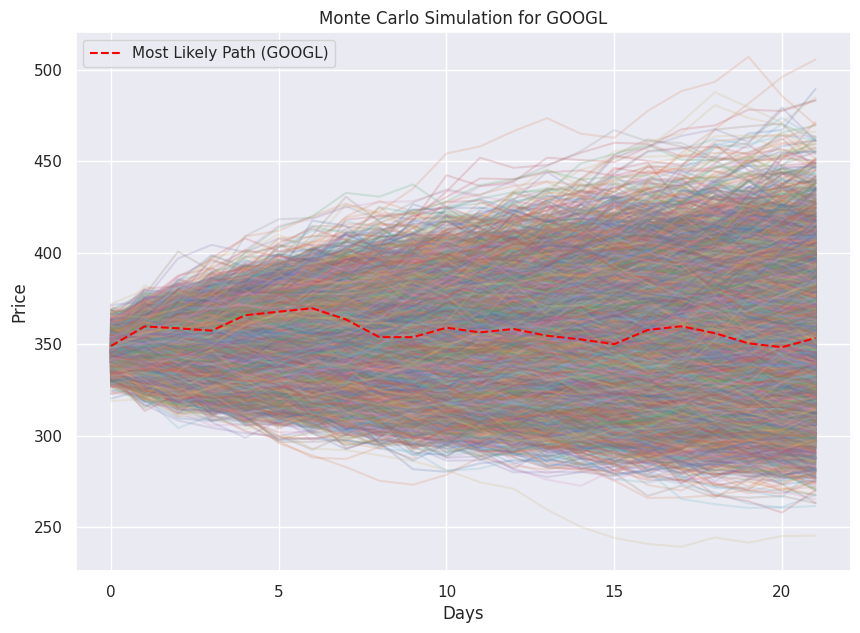

-------- Results for GOOGL ---------
Median Final Simulated Price: $353.40
Most Likely Final Simulated Price: $353.41
---------------------------------------------------------------------------


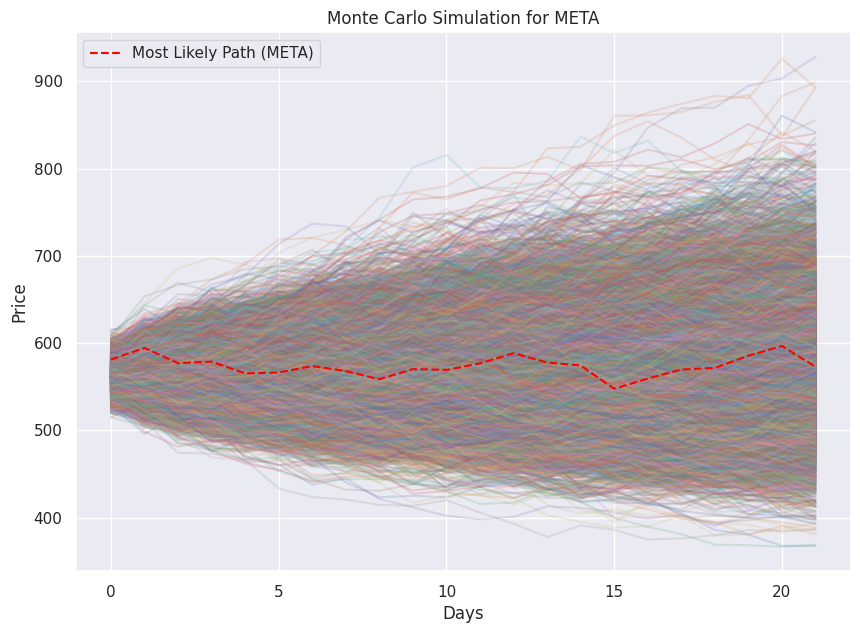

-------- Results for META ---------
Median Final Simulated Price: $572.90
Most Likely Final Simulated Price: $572.91
---------------------------------------------------------------------------


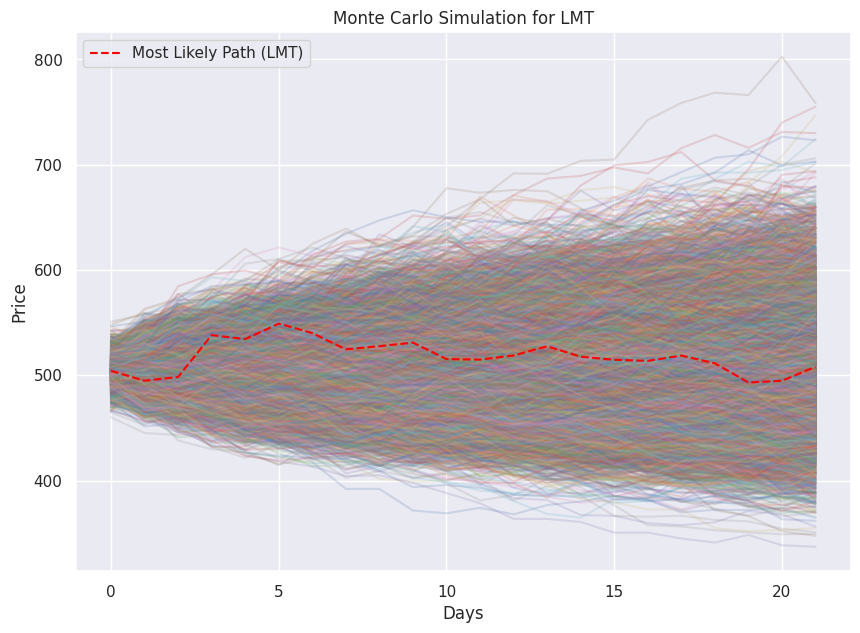

-------- Results for LMT ---------
Median Final Simulated Price: $508.12
Most Likely Final Simulated Price: $508.09
---------------------------------------------------------------------------


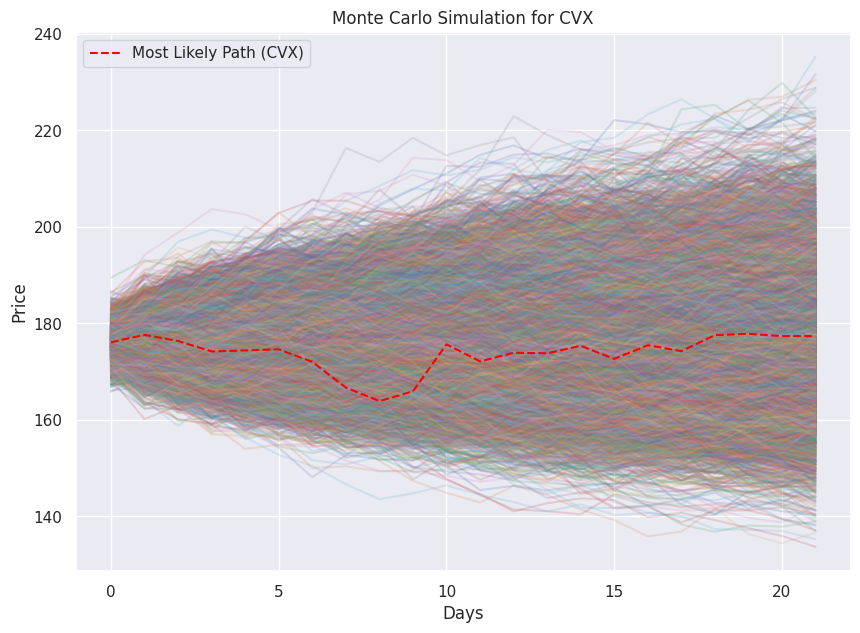

-------- Results for CVX ---------
Median Final Simulated Price: $177.36
Most Likely Final Simulated Price: $177.36
---------------------------------------------------------------------------


In [18]:
print(f'--------- Simulating for {mis_tickers} ---------')
for current_ticker in mis_tickers:
    close_prices = get_close_series(df2, current_ticker)
    simulation_df, final_prices, median_final_prices, most_likely_price_simulation = run_monte_carlo(
        close_prices,
        num_days=num_days,
        num_simulations=num_simulations,
    )

    all_ticker_simulation_dfs[current_ticker] = simulation_df
    all_ticker_most_likely_prices[current_ticker] = most_likely_price_simulation[-1]
    all_ticker_median_final_prices[current_ticker] = median_final_prices

    plt.figure(figsize=(10, 7))
    plt.plot(simulation_df, alpha=0.2)
    plt.plot(most_likely_price_simulation, color='red', linestyle='--', label=f'Most Likely Path ({current_ticker})')
    plt.title(f'Monte Carlo Simulation for {current_ticker}')
    plt.xlabel('Days')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

    print(f'-------- Results for {current_ticker} ---------')
    print(f'Median Final Simulated Price: ${all_ticker_median_final_prices[current_ticker]:.2f}')
    print(f'Most Likely Final Simulated Price: ${all_ticker_most_likely_prices[current_ticker]:.2f}')
    print('-' * 75)


In [19]:
# Consolidated summary of results for all tickers
print(f'--- Consolidated Analysis for All Tickers (Prediction Horizon: {num_days} days, Simulations: {num_simulations}) ---')
for ticker in mis_tickers:
    simulated_price = all_ticker_most_likely_prices[ticker]
    current_price = get_close_series(df2, ticker).iloc[-1]
    print(f'{ticker}: Most Likely Simulated Final Price: {simulated_price:.3f} | Current Price: {current_price:.3f}')


--- Consolidated Analysis for All Tickers (Prediction Horizon: 22 days, Simulations: 10000) ---
PLTR: Most Likely Simulated Final Price: 121.389 | Current Price: 116.700
MSFT: Most Likely Simulated Final Price: 380.252 | Current Price: 373.940
GOOGL: Most Likely Simulated Final Price: 353.409 | Current Price: 346.130
META: Most Likely Simulated Final Price: 572.907 | Current Price: 562.200
LMT: Most Likely Simulated Final Price: 508.092 | Current Price: 503.670
CVX: Most Likely Simulated Final Price: 177.365 | Current Price: 175.980


In [20]:

# Create a list to store the results
results = []

# Collect data for each ticker
for ticker in mis_tickers:
    simulated_price = all_ticker_most_likely_prices[ticker]
    results.append({
        "Ticker": ticker,
        "Most Likely Simulated Final Price": round(simulated_price, 3)
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Display the table
print(f"--- Consolidated Analysis for All Tickers (Prediction Horizon: {num_days} days, Simulations: {num_simulations}) ---")
print(results_df.to_string(index=False))

--- Consolidated Analysis for All Tickers (Prediction Horizon: 22 days, Simulations: 10000) ---
Ticker  Most Likely Simulated Final Price
  PLTR                            121.389
  MSFT                            380.252
 GOOGL                            353.409
  META                            572.907
   LMT                            508.092
   CVX                            177.365


## Distribución de Precios Finales Simulados

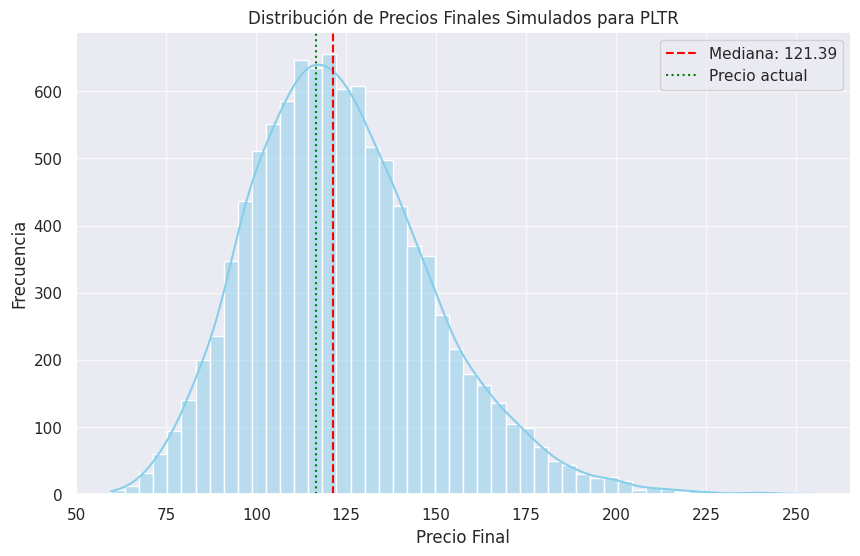

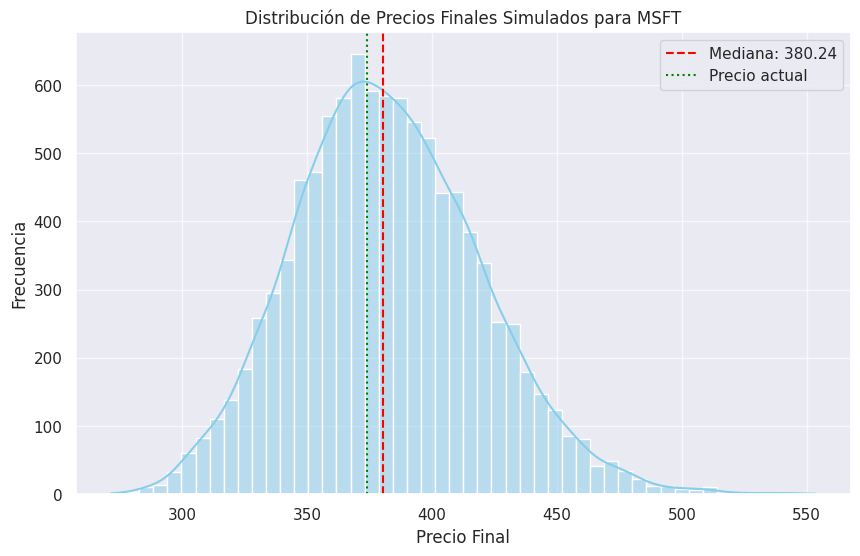

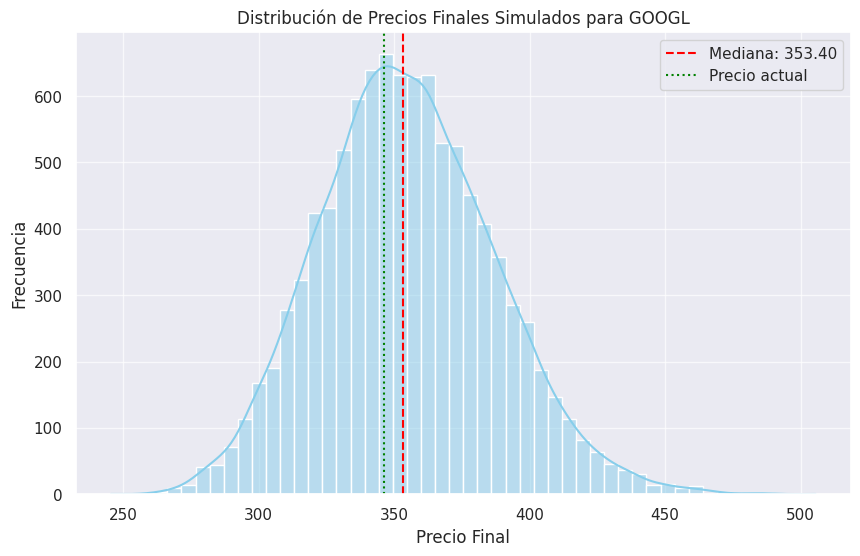

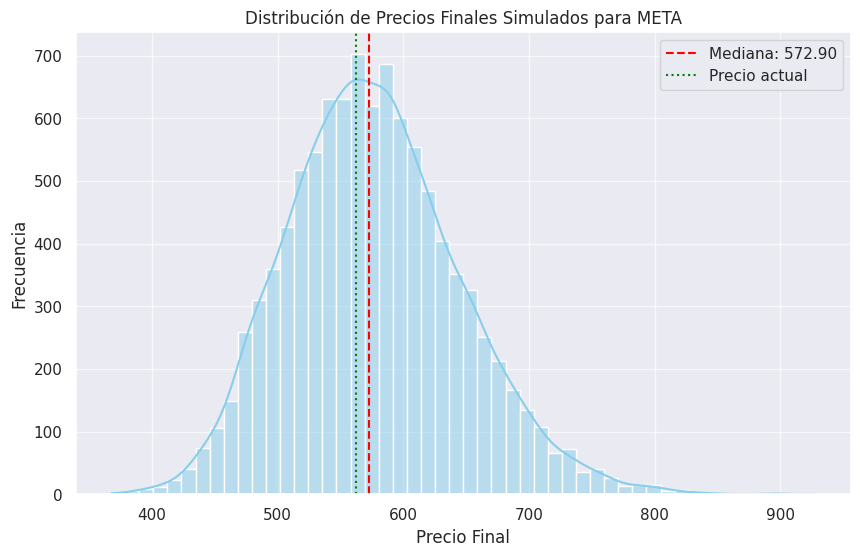

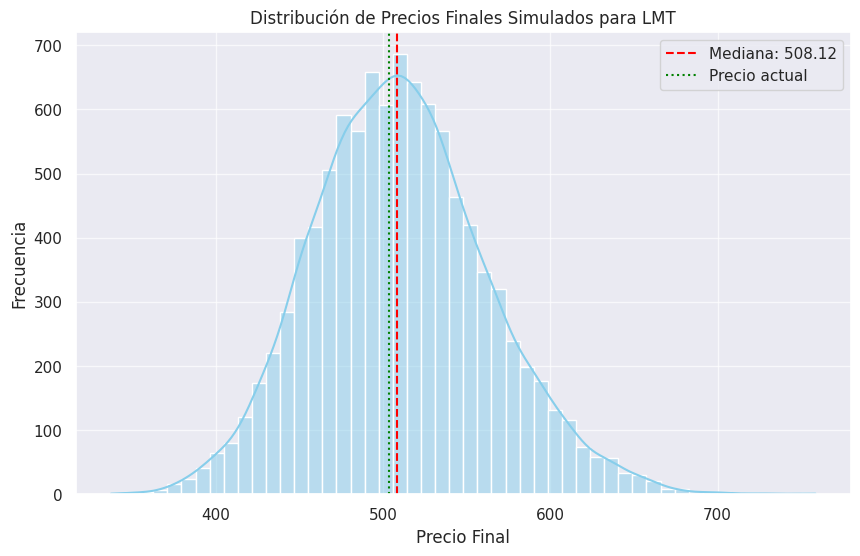

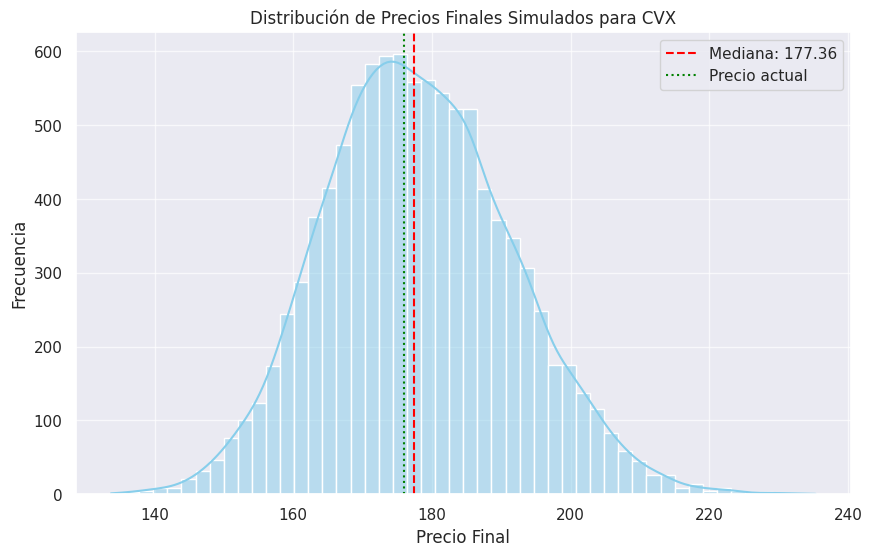

In [21]:
for ticker in mis_tickers:
    plt.figure(figsize=(10, 6))
    final_prices = all_ticker_simulation_dfs[ticker][-1, :]
    sns.histplot(final_prices, bins=50, kde=True, color='skyblue')
    plt.title(f'Distribución de Precios Finales Simulados para {ticker}')
    plt.xlabel('Precio Final')
    plt.ylabel('Frecuencia')
    plt.axvline(all_ticker_median_final_prices[ticker], color='red', linestyle='--', label=f'Mediana: {all_ticker_median_final_prices[ticker]:.2f}')
    plt.axvline(get_close_series(df2, ticker).iloc[-1], color='green', linestyle=':', label='Precio actual')
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.show()


## Intervalo de Confianza del 95% para los Precios Finales Simulados

In [22]:
print("--- 95% Confidence Interval for Simulated Final Prices ---")
for ticker in mis_tickers:
    final_prices = all_ticker_simulation_dfs[ticker][-1, :]
    lower_bound = np.percentile(final_prices, 2.5)
    upper_bound = np.percentile(final_prices, 97.5)
    print(f"{ticker}: 95% CI: [{lower_bound:.3f}, {upper_bound:.3f}]")

--- 95% Confidence Interval for Simulated Final Prices ---
PLTR: 95% CI: [80.663, 180.319]
MSFT: 95% CI: [313.318, 459.518]
GOOGL: 95% CI: [296.001, 421.331]
META: 95% CI: [455.532, 724.110]
LMT: 95% CI: [414.246, 620.628]
CVX: 95% CI: [153.135, 205.635]
